In [1]:
from google.colab import files
uploaded = files.upload()

Saving messy_customer_orders.csv to messy_customer_orders.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# I used this to upload the CSV into Colab.
from google.colab import files
uploaded = files.upload()

filename = next(iter(uploaded))
print("Loaded:", filename)

# I read the CSV so I can clean it.
df_raw = pd.read_csv(filename)
df = df_raw.copy()

df.head()

Saving messy_customer_orders.csv to messy_customer_orders (1).csv
Loaded: messy_customer_orders (1).csv


,order_id,order_date,customer_name,state,product,category,quantity,unit_price,total_price,email,notes
0,1001,1/5/2025,Alex Smith,TX,Phone Case,Accessories,2,$12.99,$25.98,alex@example.com,NaN
1,1002,1/6/2025,Jamie Lee,Texas,USB-C Cable,accessory,1,9.99,9.99,jamie@example.com,late delivery
2,1003,1/7/2025,Sam Patel,CA,Laptop Stand,Office,1,$29.99,$29.99,sam@example.com,
3,1004,1/7/2025,Sam Patel,CA,Laptop Stand,Office,1,$29.99,$29.99,sam@example.com,duplicate row
4,1005,1/8/2025,Taylor Green,Colorado,Wireless Mouse,Office,1,$19.50,$19.50,taylor@example.com,NaN


In [3]:
# I cleaned column names so they are consistent.
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(r"\s+", "_", regex=True)
)

# I removed duplicate rows so revenue isn't double counted.
df = df.drop_duplicates()

# I trimmed extra spaces in text columns.
text_cols = df.select_dtypes(include=["object"]).columns
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

df.head()

,order_id,order_date,customer_name,state,product,category,quantity,unit_price,total_price,email,notes
0,1001,1/5/2025,Alex Smith,TX,Phone Case,Accessories,2,$12.99,$25.98,alex@example.com,nan
1,1002,1/6/2025,Jamie Lee,Texas,USB-C Cable,accessory,1,9.99,9.99,jamie@example.com,late delivery
2,1003,1/7/2025,Sam Patel,CA,Laptop Stand,Office,1,$29.99,$29.99,sam@example.com,
3,1004,1/7/2025,Sam Patel,CA,Laptop Stand,Office,1,$29.99,$29.99,sam@example.com,duplicate row
4,1005,1/8/2025,Taylor Green,Colorado,Wireless Mouse,Office,1,$19.50,$19.50,taylor@example.com,nan


In [4]:
# I converted money columns into numbers by removing $ and commas.
for col in ["unit_price", "total_price"]:
    df[col] = (
        df[col].astype(str)
              .str.replace(r"[$,]", "", regex=True)
              .replace("nan", np.nan)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

# I converted quantity to a number. If it can't convert (like "one"), it becomes missing.
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")

df[["quantity","unit_price","total_price"]].head(12)

,quantity,unit_price,total_price
0,2.0,12.99,25.98
1,1.0,9.99,9.99
2,1.0,29.99,29.99
3,1.0,29.99,29.99
4,1.0,19.50,19.50
5,NaN,3.25,NaN
6,1.0,15.00,15.00
7,1.0,89.99,89.99
8,1.0,89.99,89.99
9,2.0,22.00,44.00


In [5]:
# I converted the date column into a real datetime so it can be sorted and grouped.
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

df[["order_id","order_date"]].head(10)

,order_id,order_date
0,1001,2025-01-05
1,1002,2025-01-06
2,1003,2025-01-07
3,1004,2025-01-07
4,1005,2025-01-08
5,1006,2025-01-09
6,1007,2025-01-10
7,1008,2025-01-11
8,1009,2025-01-12
9,1010,2025-01-13


In [10]:
# I standardized states but I keep the original if it isn't in my map.
state_map = {
    "texas": "TX", "tx": "TX",
    "colorado": "CO", "co": "CO",
    "new york": "NY", "ny": "NY",
    "california": "CA", "ca": "CA"
}

# I clean the text first so the mapping works better.
state_clean = (
    df["state"]
      .replace("nan", np.nan)
      .astype(str)
      .str.strip()
      .str.lower()
)

# I map known values, but if it doesn't match, I keep what was there.
mapped = state_clean.map(state_map)
df["state"] = mapped.fillna(state_clean.str.upper())

# I replace empty strings with "Unknown" so they don't stay blank.
df["state"] = df["state"].replace({"": "Unknown", "NONE": "Unknown", "NAN": "Unknown"}).fillna("Unknown")

df[["state"]].head(12)

,state
0,TX
1,TX
2,CA
3,CA
4,CO
5,CO
6,UNKNOWN
7,NY
8,NY
9,CA


In [11]:
# I filled missing values so the dataset is usable.
df["product"] = df["product"].replace("nan", np.nan).fillna("Unknown Product")
df["state"] = df["state"].fillna("Unknown")
df["quantity"] = df["quantity"].fillna(1)

# I recomputed total_price if it is missing (quantity * unit_price).
missing_total = df["total_price"].isna() & df["unit_price"].notna()
df.loc[missing_total, "total_price"] = df.loc[missing_total, "quantity"] * df.loc[missing_total, "unit_price"]

df[["order_id","product","quantity","unit_price","total_price","state","category"]].head(15)

,order_id,product,quantity,unit_price,total_price,state,category
0,1001,Phone Case,2.0,12.99,25.98,TX,Accessories
1,1002,USB-C Cable,1.0,9.99,9.99,TX,Accessory
2,1003,Laptop Stand,1.0,29.99,29.99,CA,Office
3,1004,Laptop Stand,1.0,29.99,29.99,CA,Office
4,1005,Wireless Mouse,1.0,19.50,19.50,CO,Office
5,1006,Notebook,1.0,3.25,3.25,CO,Office
6,1007,Water Bottle,1.0,15.00,15.00,UNKNOWN,Accessories
7,1008,Headphones,1.0,89.99,89.99,NY,Electronics
8,1009,Headphones,1.0,89.99,89.99,NY,Electronics
9,1010,Desk Lamp,2.0,22.00,44.00,CA,Home


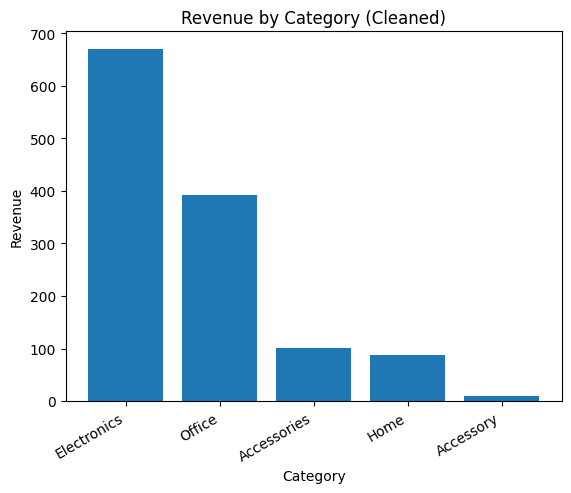

In [12]:
# I grouped revenue by category to check if the cleaned data makes sense.
rev_by_cat = df.groupby("category")["total_price"].sum().sort_values(ascending=False)

plt.figure()
plt.bar(rev_by_cat.index, rev_by_cat.values)
plt.title("Revenue by Category (Cleaned)")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=30, ha="right")
plt.show()

In [9]:
# I saved the cleaned dataset so I can submit it.
from google.colab import files
cleaned_name = "cleaned_" + filename
df.to_csv(cleaned_name, index=False)
files.download(cleaned_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>